In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('global_sports_footwear_sales_2018_2026.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


## Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30000 non-null  object 
 1   order_date             30000 non-null  object 
 2   brand                  30000 non-null  object 
 3   model_name             30000 non-null  object 
 4   category               30000 non-null  object 
 5   gender                 30000 non-null  object 
 6   size                   30000 non-null  int64  
 7   color                  30000 non-null  object 
 8   base_price_usd         30000 non-null  int64  
 9   discount_percent       30000 non-null  int64  
 10  final_price_usd        30000 non-null  float64
 11  units_sold             30000 non-null  int64  
 12  revenue_usd            30000 non-null  float64
 13  payment_method         30000 non-null  object 
 14  sales_channel          30000 non-null  object 
 15  co

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
# df['order_date'] = df['order_date'].dt.strftime('%d/%m/%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               30000 non-null  object        
 1   order_date             30000 non-null  datetime64[ns]
 2   brand                  30000 non-null  object        
 3   model_name             30000 non-null  object        
 4   category               30000 non-null  object        
 5   gender                 30000 non-null  object        
 6   size                   30000 non-null  int64         
 7   color                  30000 non-null  object        
 8   base_price_usd         30000 non-null  int64         
 9   discount_percent       30000 non-null  int64         
 10  final_price_usd        30000 non-null  float64       
 11  units_sold             30000 non-null  int64         
 12  revenue_usd            30000 non-null  float64       
 13  p

## Feature Engineering

In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [ ]:
df['week'] = df['order_date'].dt.day_name()
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month_name()

# discount = (df['discount_percent'] / 100) * df['base_price_usd']

# df['final_price_usd'] = df['base_price_usd'] - discount

# df['revenue_usd'] = df['final_price_usd'] * df['units_sold']

df['discount'] = df['base_price_usd'] - df['final_price_usd']

df['discount_rate'] = df['base_price_usd'] - df['final_price_usd'] / df['base_price_usd'] * 100


df.head()


,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,week,year,month,discount,discount_rate
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6,Saturday,2021,January,24.30,77.0
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9,Monday,2026,October,4.00,-15.0
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0,Sunday,2023,November,26.40,91.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4,Saturday,2026,August,9.15,-24.0
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0,Saturday,2019,November,0.00,-20.0


## Missing

In [ ]:
df.isna().sum()

order_id                 0
order_date               0
brand                    0
model_name               0
category                 0
gender                   0
size                     0
color                    0
base_price_usd           0
discount_percent         0
final_price_usd          0
units_sold               0
revenue_usd              0
payment_method           0
sales_channel            0
country                  0
customer_income_level    0
customer_rating          0
week                     0
year                     0
month                    0
discount                 0
discount_rate            0
dtype: int64

## Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

## Outlier

<Axes: >

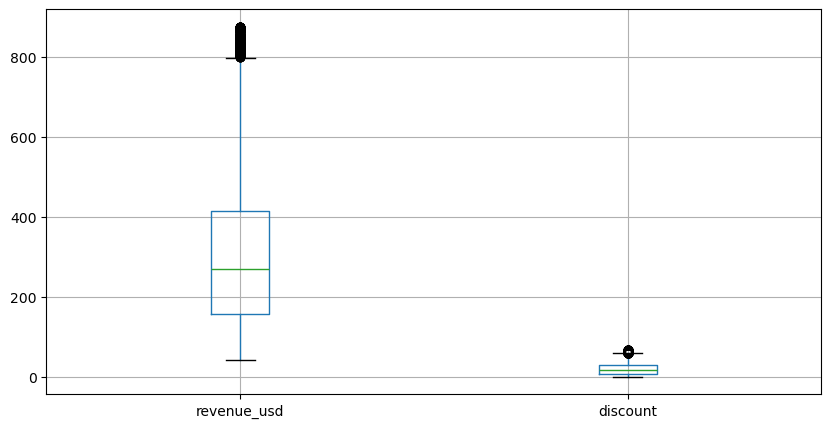

In [ ]:
plt.figure(figsize=(10,5))
df[['revenue_usd', 'discount']].boxplot()

In [ ]:
Q1 = df["discount"].quantile(0.25)
Q3 = df["discount"].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR
higher = Q3 + 1.5 * IQR


   # df["discount"] = np.clip(df["discount"], lower, upper)

outlier = df[(df["discount"] < lower) | (df["discount"] > higher)]

outlier.min()

order_id                           ORD100037
order_date               2018-01-07 00:00:00
brand                                  ASICS
model_name                         Model-100
category                          Basketball
gender                                   Men
size                                       6
color                                  Black
base_price_usd                           200
discount_percent                          30
final_price_usd                        140.0
units_sold                                 1
revenue_usd                            140.0
payment_method                 Bank Transfer
sales_channel                         Online
country                              Germany
customer_income_level                   High
customer_rating                          3.0
week                                  Friday
year                                    2018
month                                  April
discount                                60.0
discount_r

In [ ]:
columns = ['revenue_usd', 'discount']

for column in columns:

   Q1 = df[column].quantile(0.25)
   Q3 = df[column].quantile(0.75)

   IQR = Q3-Q1

   lower = Q1 - 1.5 * IQR
   higher = Q3 + 1.5 * IQR


   # df[column] = np.clip(df[column], lower, upper)

   outlier = df[(df[column] < lower) | (df[column] > higher)]

# i checked the lower limit and higher limit of the dataset and found out that the "revenue_usd" that are higher and lower are normal

## Correlation

In [ ]:
df['discount_rate'] = df['discount_rate'].abs()

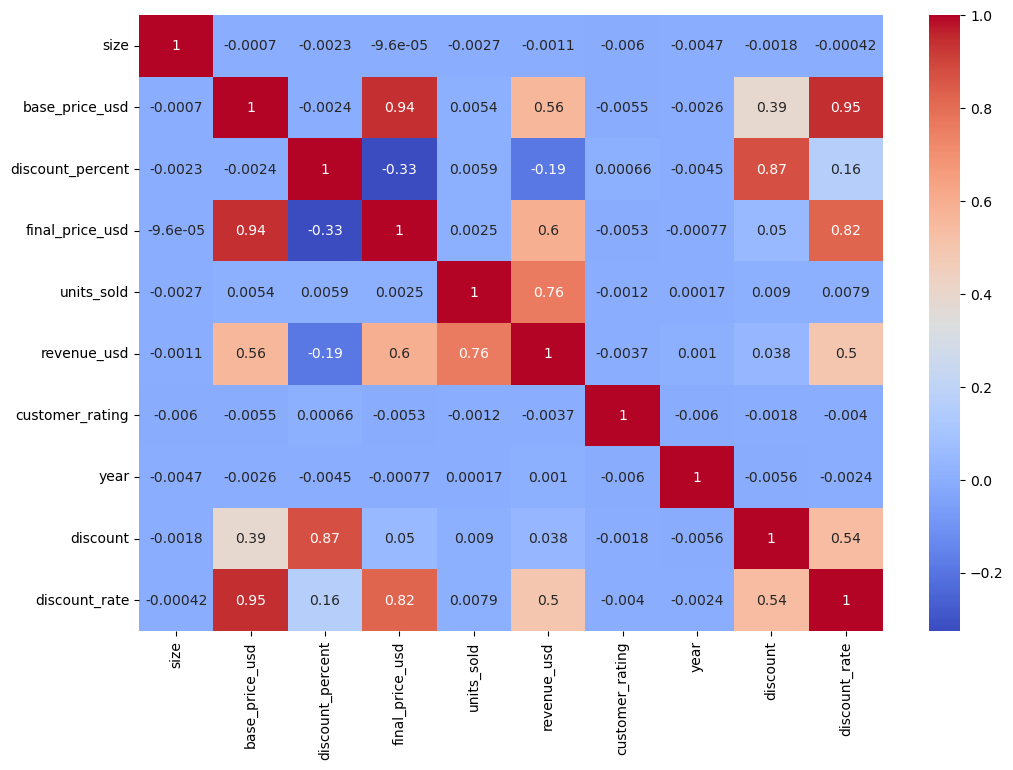

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Insights

In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,week,year,month,discount,discount_rate
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6,Saturday,2021,January,24.30,77.0
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9,Monday,2026,October,4.00,15.0
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0,Sunday,2023,November,26.40,91.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4,Saturday,2026,August,9.15,24.0
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0,Saturday,2019,November,0.00,20.0


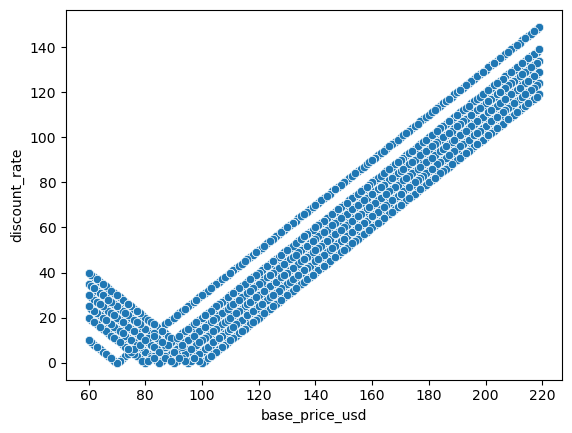

In [ ]:
sns.scatterplot(data=df, x='base_price_usd', y='discount_rate')
plt.show()

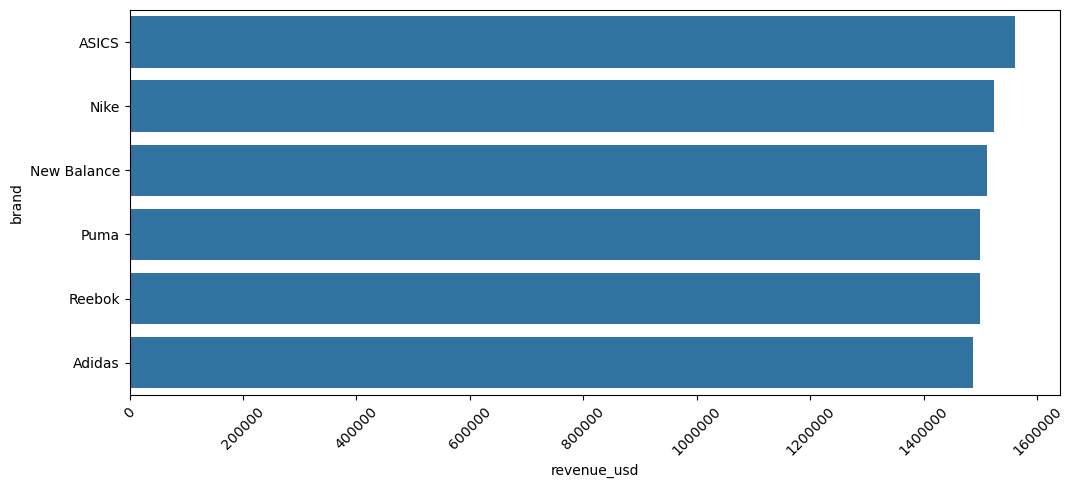

In [ ]:
which_brand_made_more_revenue = df.groupby('brand')['revenue_usd'].sum().reset_index()
which_brand_made_more_revenue =  which_brand_made_more_revenue.sort_values('revenue_usd', ascending=False)

plt.figure(figsize=(12,5))

sns.barplot(data=which_brand_made_more_revenue, x='revenue_usd', y='brand')
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)
plt.show()

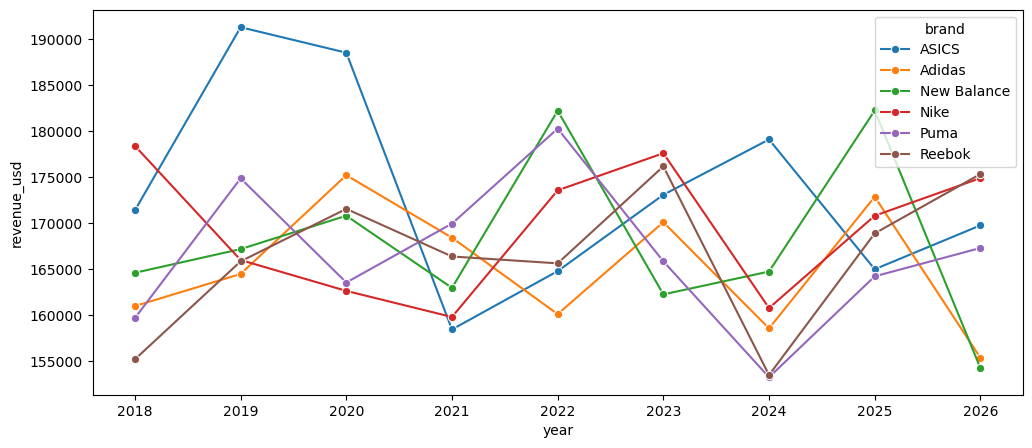

In [ ]:
which_year_brought_in_more_sales = df.groupby(['year', 'brand'])['revenue_usd'].sum().reset_index() 

plt.figure(figsize=(12,5))

sns.lineplot(data=which_year_brought_in_more_sales, x='year', y='revenue_usd', marker='o', hue='brand')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,week,year,month,discount,discount_rate
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6,Saturday,2021,January,24.30,77.0
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9,Monday,2026,October,4.00,15.0
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0,Sunday,2023,November,26.40,91.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4,Saturday,2026,August,9.15,24.0
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0,Saturday,2019,November,0.00,20.0


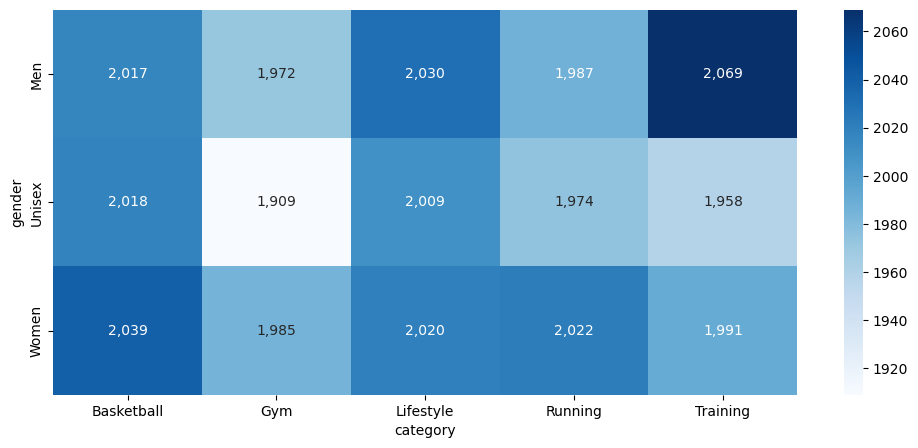

In [ ]:
which_category_did_each_gender_bought = pd.crosstab(df['gender'], df['category'])

plt.figure(figsize=(12,5))
sns.heatmap(data=which_category_did_each_gender_bought, annot=True, cmap='Blues', fmt=',.0f')

# df[(df['category'] == 'Basketball') & (df['gender'] == 'Men')]


plt.show()


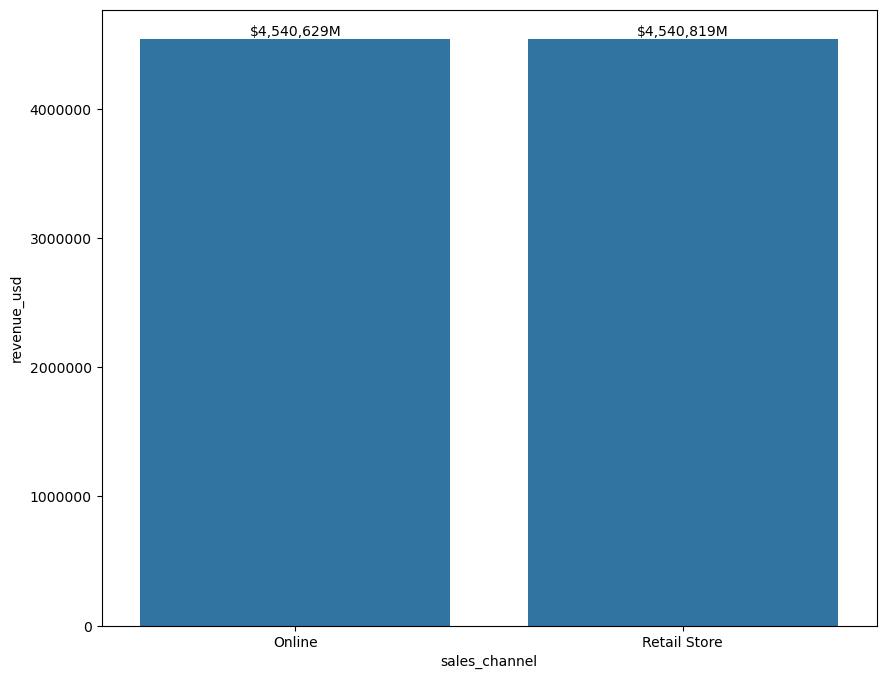

In [ ]:
which_retail_store_brought_in_more_sales = df.groupby('sales_channel')['revenue_usd'].sum().reset_index()

plt.figure(figsize=(10,8))
ax = sns.barplot(data=which_retail_store_brought_in_more_sales, x='sales_channel', y='revenue_usd')
for p in ax.patches:
    ax.annotate(
        f'${p.get_height():,.0f}M',
        (
            p.get_x() + p.get_width() / 2, p.get_height()
        ),
        ha='center',
        va='bottom'
    )
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Time Series Analysis

In [ ]:
df = df.sort_values('order_date')

In [ ]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating,week,year,month,discount,discount_rate
7536,ORD107536,2018-01-01,Reebok,Model-432,Running,Men,10,Grey,91,30,63.70,2,127.40,Bank Transfer,Retail Store,India,Low,3.3,Monday,2018,January,27.30,21.0
7881,ORD107881,2018-01-01,ASICS,Model-674,Lifestyle,Women,9,White,217,15,184.45,1,184.45,Bank Transfer,Online,USA,Medium,3.0,Monday,2018,January,32.55,132.0
21309,ORD121309,2018-01-01,Adidas,Model-512,Running,Women,10,White,191,5,181.45,1,181.45,Wallet,Online,USA,Low,5.0,Monday,2018,January,9.55,96.0
5845,ORD105845,2018-01-01,Puma,Model-874,Running,Unisex,7,Grey,165,10,148.50,1,148.50,Wallet,Retail Store,USA,High,4.6,Monday,2018,January,16.50,75.0
14642,ORD114642,2018-01-01,New Balance,Model-927,Gym,Women,10,Red,117,0,117.00,1,117.00,Cash,Online,Pakistan,High,4.4,Monday,2018,January,0.00,17.0


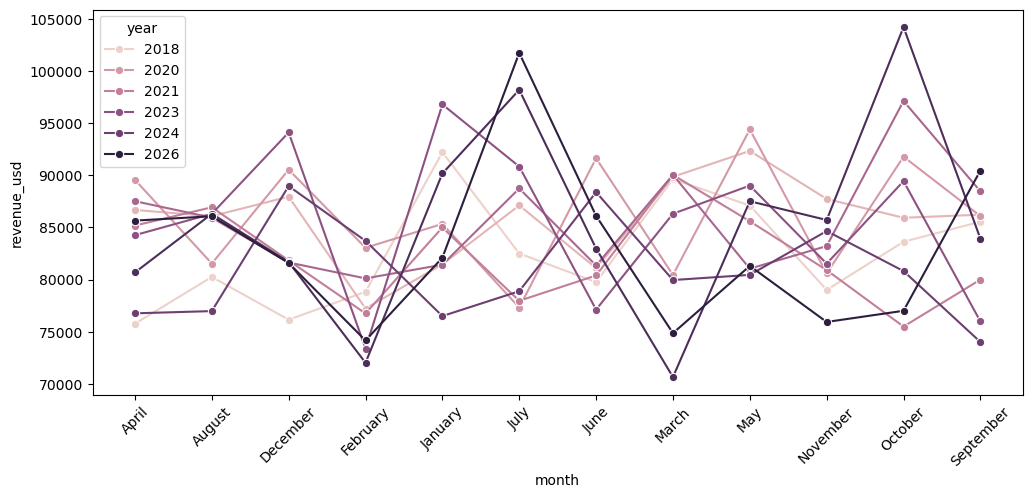

In [ ]:
monthly = df.groupby(['month', 'year'])['revenue_usd'].sum().reset_index()
plt.figure(figsize=(12,5))

sns.lineplot(data=monthly, x='month', y='revenue_usd', hue='year', marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()

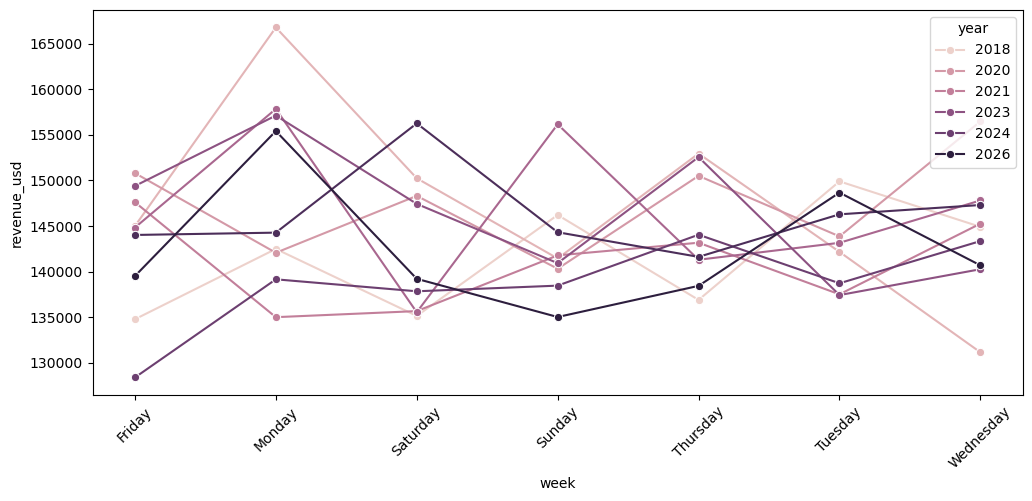

In [ ]:
week = df.groupby(['week', 'year'])['revenue_usd'].sum().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(data=week, x='week', y='revenue_usd', hue='year', marker='o')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.to_excel('footware_sales.xlsx', index=False)